In [1]:
!pip install gdeltdoc
!pip install lxml
!pip install Pillow
!pip install newspaper3k
!pip install lxml[html_clean]
!pip install openai==0.28

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 34.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 86.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.1/211.1 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.3/81.3 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━

In [6]:
import os
import openai
from gdeltdoc import GdeltDoc, Filters
from newspaper import Article
import json
import pandas as pd
from tqdm import tqdm

# --- OpenAI API 키 설정 ---
os.environ["OPENAI_API_KEY"] = "your own open-ai key" #openai 키 입력
openai.api_key = os.environ["OPENAI_API_KEY"]

# --- 모델 선택 ---
model = "gpt-3.5-turbo-0125"

# --- GPT 호출 함수 ---
def chatgpt_generate(query):
    messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": query}
    ]
    response = openai.ChatCompletion.create(model=model, messages=messages)
    return response['choices'][0]['message']['content']

# --- GDELT 필터링 후 기사 목록 수집 ---
gd = GdeltDoc()

def get_url(keyword):
    f = Filters(
        start_date="2024-03-20",
        end_date="2024-03-25",
        num_records=10,
        keyword=keyword,
        domain="nytimes.com",
        country="US"
    )
    articles = gd.article_search(f)
    return articles

# --- 뉴스 기사 본문 크롤링 ---
def url_crawling(df):
    urls = df["url"]
    texts = []
    for url in tqdm(urls, desc="기사 본문 수집 중"):
        try:
            article = Article(url)
            article.download()
            article.parse()
            texts.append(article.text)
        except Exception as e:
            print(f"[오류 발생] {url}: {e}")
            texts.append("")
    return texts

# --- 프롬프트 정의 ---
prompt = '''아래 뉴스에서 기업명을 모두 추출하고, 기업에 해당하는 감성을 분석하시오.
각 감성에 스코어링을 하시오. 각 스코어의 합은 1이 되어야 합니다. 소수점 첫번째까지만 생성하세요.
출력포맷은 리스트이며, 세부 내용은 다음과 같습니다.
반드시 출력포맷만을 생성하시오. 그 이외의 단어나 설명은 생성하지마시오.
[{"organization": <기업명>, "positive": 0~1, "negative": 0~1, "neutral": 0~1}, ...]

뉴스: '''

# --- 메인 처리 로직 ---
orgs = ["microsoft", "apple"]  # 분석할 키워드
result = []

for org in orgs:
    df = get_url(org)
    texts = url_crawling(df)

    for text in texts:
        if not text.strip():
            continue  # 본문이 비어있으면 건너뜀

        full_prompt = prompt + text
        answer = chatgpt_generate(full_prompt)

        # 마크다운 제거
        cleaned = answer.strip()
        if cleaned.startswith("```json"):
            cleaned = cleaned.replace("```json", "").strip()
        if cleaned.endswith("```"):
            cleaned = cleaned.replace("```", "").strip()

        try:
            parsed = json.loads(cleaned)
            result.append(parsed)
        except Exception as e:
            print("❌ JSON 파싱 실패 응답:\n", answer)
            print("에러:", e)

# --- 결과 출력 ---
print("✅ 전체 결과:")
print(json.dumps(result, indent=2, ensure_ascii=False))

# --- 결과를 DataFrame으로 저장 (옵션) ---
flattened = []
for items in result:
    if isinstance(items, list):
      flattened.extend(items)

df_result = pd.DataFrame(flattened)
df_result.to_csv("gpt_sentiment_result.csv", index=False, encoding="utf-8-sig")
print("CSV 저장 완료: gpt_sentiment_result.csv")


기사 본문 수집 중: 100%|██████████| 10/10 [00:07<00:00,  1.39it/s]


✅ 전체 결과:
[
  [
    {
      "organization": "Microsoft",
      "positive": 0.6,
      "negative": 0.1,
      "neutral": 0.3
    },
    {
      "organization": "Apple",
      "positive": 0.4,
      "negative": 0.2,
      "neutral": 0.4
    },
    {
      "organization": "Google",
      "positive": 0.5,
      "negative": 0.2,
      "neutral": 0.3
    },
    {
      "organization": "DeepMind",
      "positive": 0.7,
      "negative": 0.1,
      "neutral": 0.2
    },
    {
      "organization": "Inflection AI",
      "positive": 0.6,
      "negative": 0.2,
      "neutral": 0.2
    },
    {
      "organization": "LinkedIn",
      "positive": 0.4,
      "negative": 0.3,
      "neutral": 0.3
    }
  ],
  [
    {
      "organization": "Apple",
      "positive": 0.3,
      "negative": 0.4,
      "neutral": 0.3
    },
    {
      "organization": "Google",
      "positive": 0.6,
      "negative": 0.2,
      "neutral": 0.2
    },
    {
      "organization": "Microsoft",
      "positive": 0.2,
     

In [8]:
# 한글 폰트 설치
!apt-get -qq install -y fonts-nanum
!fc-cache -fv

Selecting previously unselected package fonts-nanum.
(Reading database ... 126101 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory det

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

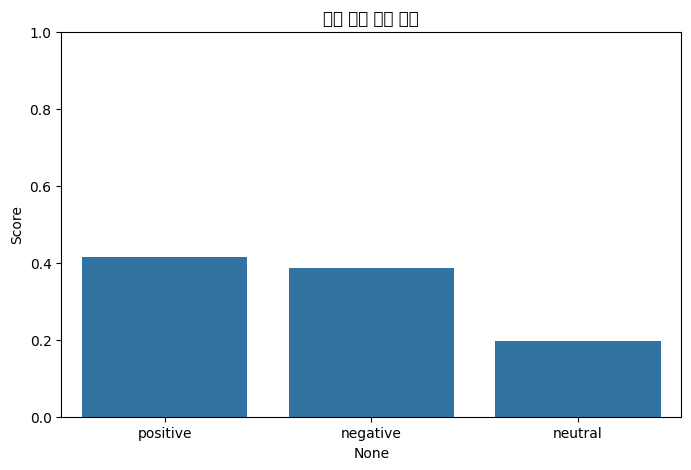

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51649 (\N{HANGUL SYLLABLE JIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50892 (\N{HANGUL SYLLABLE WEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

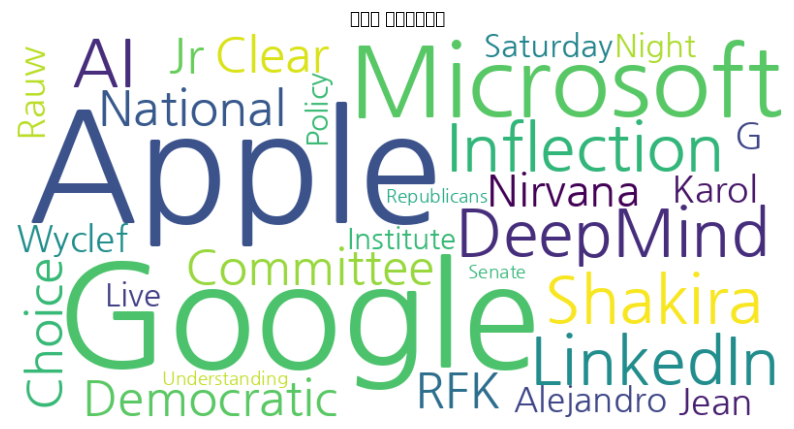

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# -------- 1. CSV 불러오기 --------
df = pd.read_csv("gpt_sentiment_result.csv")

# -------- 2. 감성 점수 막대그래프 --------
def plot_sentiment_bar(df):
    sentiments = df[['positive', 'negative', 'neutral']].mean()
    sentiments = sentiments.sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=sentiments.index, y=sentiments.values)
    plt.title("전체 평균 감성 점수")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.show()


from wordcloud import WordCloud
import matplotlib.pyplot as plt

FONT_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

# -------- 3. 조직명 기반 워드클라우드 --------
def plot_wordcloud(df):
    text = " ".join(df['organization'].dropna().astype(str).tolist())

    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        font_path=FONT_PATH  # ✅ 한글 폰트 적용
    ).generate(text)

    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title("조직명 워드클라우드")
    plt.show()

# -------- 4. 감성 점수 시계열 분석 --------
def plot_time_series(df_full):
    # 감성 결과와 날짜 결합
    df_sent = pd.read_csv("gpt_sentiment_result.csv")
    df_full = df_full.reset_index(drop=True)  # 기존 기사 df (GDELT 결과 포함)

    # 병합
    df_sent['date'] = df_full['date'].astype(str).str[:10]  # 날짜만 남김
    df_sent['organization'] = df_sent['organization'].astype(str)

    # 시계열 평균 감성 점수
    df_grouped = df_sent.groupby(['date', 'organization'])[['positive', 'negative', 'neutral']].mean().reset_index()

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_grouped, x='date', y='positive', hue='organization', marker="o", label="Positive")
    plt.title("일자별 기업 감성 추이 (Positive)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_grouped, x='date', y='negative', hue='organization', marker="o", label="Negative")
    plt.title("일자별 기업 감성 추이 (Negative)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# -------- 실행 --------
plot_sentiment_bar(df)
plot_wordcloud(df)
